In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Part A — Data preparation (must-have)

In [2]:
trades = pd.read_csv("historical_data.csv")

In [3]:
sentiment = pd.read_csv("fear_greed_index.csv")

In [4]:
trades.shape  # number of records in dataset

(211224, 16)

In [5]:
sentiment.shape # number of records in dataset

(2644, 4)

In [6]:
trades.isnull().sum() # checking nullvalues

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
sentiment.isnull().sum() # checking null values

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [8]:
trades.duplicated().sum()  # Checking Any duplicates values

np.int64(0)

In [9]:
sentiment.duplicated().sum()  # checking any duplicates values

np.int64(0)

In [10]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [13]:
sentiment['date'].head(10)

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
5    2018-02-06
6    2018-02-07
7    2018-02-08
8    2018-02-09
9    2018-02-10
Name: date, dtype: object

In [14]:
sentiment['date'].min()

'2018-02-01'

In [15]:
sentiment['date'].max()

'2025-05-02'

In [16]:
sentiment['date'].dtype

dtype('O')

In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [18]:
sentiment['date'].dtype

dtype('<M8[ns]')

In [19]:
sentiment['date'].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]

In [20]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [22]:
trades['Timestamp'].min()

1680000000000.0

In [23]:
trades['Timestamp'].max()

1750000000000.0

In [24]:
trades['Timestamp'].dtype

dtype('float64')

In [25]:
trades['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [26]:
trades['Timestamp'].isnull().sum()

np.int64(0)

In [27]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms',
    errors='coerce'
)

In [28]:
trades['Timestamp'].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [29]:
trades['Timestamp'].isnull().sum()

np.int64(0)

In [30]:
trades['Timestamp'].dtype

dtype('<M8[ns]')

In [31]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20


In [32]:
# syncing the date

trades = trades.sort_values('Timestamp')
sentiment = sentiment.sort_values('date')

df = pd.merge_asof(
    trades,
    sentiment,
    left_on='Timestamp',
    right_on='date',
    direction='backward'
)

In [33]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,value,classification,date
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,1679981400,59,Greed,2023-03-28
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,1679981400,59,Greed,2023-03-28
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,1679981400,59,Greed,2023-03-28
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20,1699939800,69,Greed,2023-11-14
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20,1699939800,69,Greed,2023-11-14


In [34]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
timestamp           0
value               0
classification      0
date                0
dtype: int64

### Create the key metrics you will analyze, for example:

In [35]:
# daily PnL per trader (or per account) . PnL-- Profit and loss
'''closed pnl in trade
Closed PNL, or Realized PNL, is the actual profit or loss that becomes final after a trade is closed. 

It is calculated by taking the difference between the average close price and the average entry price, multiplied by the position size.
Closed PnL = Profit or Loss from trades that are already finished (closed positions)

👉 In simple words:

It tells you how much money a trader actually earned or lost after exiting a trade'''

# “How much profit/loss each trader made per day”
daily_pnl = df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

In [36]:
daily_pnl.head()

,date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [81]:
df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            51.562465
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [82]:
df['classification'].value_counts()

classification
Fear             133871
Greed             63250
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

### Insight:
- Traders achieve the highest average PnL during Greed and Fear conditions.
- Extreme Greed shows lower profitability, possibly due to overtrading.

### Interpretation:
This suggests that moderate sentiment conditions provide more stable trading opportunities, while excessive optimism may lead to riskier behavior.

In [37]:
#○	win rate, average trade size
df['win'] = (df['Closed PnL'] > 0).astype(int)

In [38]:
df.sample(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,value,classification,date,win
121670,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,13.083000,153.300,2005.62,BUY,12-03-2025 15:19,3795.398549,Buy,0.000000,...,79307115482,True,0.045990,3.010000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,0
170440,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,SOL,198.850000,0.770,153.11,SELL,09-02-2025 19:01,-142.710000,Open Short,0.000000,...,70953027936,True,0.045934,1.810000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,0
41984,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,13.290000,0.870,11.56,SELL,10-12-2024 11:34,55721.592180,Sell,-0.040794,...,54196765929,False,0.000000,1.120000e+15,2024-10-27 03:33:20,1730007000,74,Greed,2024-10-27,0
126584,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,13.265000,39.710,526.75,BUY,12-03-2025 14:48,68417.300000,Open Long,0.000000,...,79163103798,False,0.026337,4.390000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,0
93947,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,12.588000,19.640,247.23,BUY,29-03-2025 16:23,23666.540000,Open Long,0.000000,...,82488183861,True,0.074168,1.790000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,0
57326,0xb899e522b5715391ae1d4f137653e7906c5e2115,SOL,135.910000,11.000,1495.01,SELL,04-03-2025 07:17,2280.260000,Close Long,7.277600,...,76863926973,True,0.502322,8.080000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,1
67145,0x2c229d22b100a7beb69122eed721cee9b24011dd,ALT,0.040226,1243.000,50.00,SELL,26-03-2025 23:41,819582.000000,Close Long,1.852070,...,81966105176,False,0.005000,6.650000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,1
110681,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,20.600000,0.580,11.95,SELL,20-01-2025 07:38,991.747129,Sell,0.074604,...,64552511525,False,0.001194,1.070000e+15,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,1
30990,0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,FARTCOIN,0.752400,3270.800,2460.95,SELL,22-12-2024 06:28,-113460.600000,Open Short,0.000000,...,57569962421,True,0.861332,1.120000e+15,2024-10-27 03:33:20,1730007000,74,Greed,2024-10-27,0
98710,0x271b280974205ca63b716753467d5a371de622ab,PAXG,3085.500000,1.805,5569.33,BUY,09-04-2025 23:38,-95.346000,Close Short,6.122560,...,85379430895,False,0.534654,5.630000e+14,2025-02-19 21:20:00,1739943000,44,Fear,2025-02-19,1


In [39]:
# win rate ---->>"% of trades where trader made profit"

win_rate = df.groupby('Account')['win'].mean().reset_index()

In [40]:
win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [41]:
# Average Trade Size. Means----->>>"On average, how big trades a trader takes"

avg_size = df.groupby('Account')['Size USD'].mean().reset_index()

In [42]:
avg_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [43]:
#	leverage distribution. Means---->> "How leverage values are spread across trades/traders"

In [44]:
#	number of trades per day

trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

In [45]:
trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


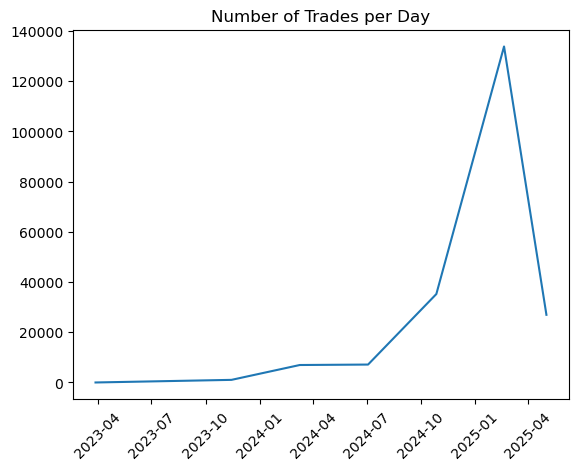

In [46]:
plt.plot(trades_per_day['date'], trades_per_day['num_trades'])
plt.xticks(rotation=45)
plt.title("Number of Trades per Day")
plt.show()

In [47]:
# long/short ratio. Means--->>"Ratio of Buy (Long) trades vs Sell (Short) trades"
# long=80,short=20 then --> 80/20=4

df['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [48]:
side_counts = df['Side'].value_counts()

In [49]:
buy_count = side_counts.get('BUY', 0)   # or 'Long'
sell_count = side_counts.get('SELL', 0) # or 'Short'

long_short_ratio = buy_count / sell_count
print(long_short_ratio)

0.9462627156125608


### Part B — Analysis (must-have)

In [50]:
#  1.	Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

daily_metrics = df.groupby(['date']).agg({
    'Closed PnL': 'sum',
    'win': 'mean'
}).reset_index()

In [51]:
daily_metrics = daily_metrics.merge(sentiment, on='date', how='left')

In [52]:
daily_metrics.isnull().sum()

date              0
Closed PnL        0
win               0
timestamp         0
value             0
classification    0
dtype: int64

In [53]:
daily_metrics.groupby('classification')['Closed PnL'].mean()



classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            8.153315e+05
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64

### Trader profitability is highest during Fear conditions, suggesting that cautious market environments lead to more disciplined and profitable trading. In contrast, profitability declines during Greed phases, likely due to overconfidence and increased risk-taking. Extreme Fear conditions show minimal profitability, indicating reduced trading activity and uncertainty.("Above metrics insight")

In [54]:
daily_metrics.groupby('classification')['win'].mean()

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.268854
Neutral          0.317182
Name: win, dtype: float64

### Win rate is highest during Greed phases, indicating that traders experience more frequent successful trades in trending markets. However, despite higher win rates, overall profitability is lower compared to Fear phases, suggesting that profits per trade are smaller or losses are larger. This highlights that win rate alone is not sufficient to determine trading performance

In [55]:
daily_metrics.groupby('classification')['Closed PnL'].std()

classification
Extreme Greed             NaN
Fear                      NaN
Greed            1.583113e+06
Neutral                   NaN
Name: Closed PnL, dtype: float64

### Insight
    1 Fear = High Risk, High Reward
    2 Greed = High Win Rate, Lower Profit
    3 Extreme Fear = Safe but Unprofitable
    4 Extreme Greed = Risky & unstable

Performance varies significantly across sentiment regimes. Fear phases exhibit the highest average PnL but also the highest volatility, indicating a high-risk, high-reward environment. Greed phases show the highest win rates but lower overall profitability, suggesting frequent but smaller gains. Extreme Fear conditions result in low volatility and minimal profitability, indicating reduced trading activity. Overall, trader performance is strongly influenced by market sentiment, with different risk-return profiles across regimes.

In [56]:
daily_metrics[daily_metrics['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()

Series([], Name: Closed PnL, dtype: float64)

### Insight
    1 Greed → high win rate BUT huge losses when wrong
    2 Fear → better balance (good profit, controlled loss)

Loss severity is significantly higher during Greed and Extreme Greed phases, indicating that traders take excessive risks and incur larger losses when wrong. In contrast, losses during Fear phases are relatively smaller, suggesting more disciplined risk management. This highlights that while Greed may increase trading activity, it also amplifies downside risk

<Axes: xlabel='classification', ylabel='Closed PnL'>

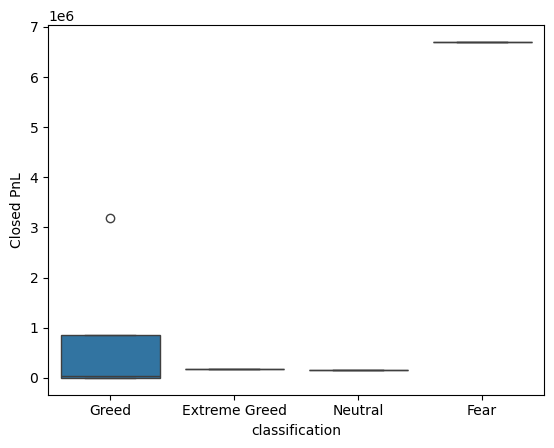

In [57]:
sns.boxplot(x='classification', y='Closed PnL', data=daily_metrics)

In [58]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.60000,0.0722,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0824,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00
83769,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.90000,0.0967,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.000000,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00
39280,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,SEI,0.44868,15078.0000,6765.20,SELL,28-12-2023 06:52,37599.0000,Close Long,-160.580700,0x9b7ba6519a89bd5e6b6c0406d51c4e018900ed590f91...,5616798569,True,1.691299,2.830000e+14,2023-11-14 22:13:20
39641,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,NTRN,1.46680,3348.0000,4910.85,SELL,07-01-2024 06:27,14206.0000,Close Long,-13.432176,0xb67de434008561227fdb0407066fc70125000f2c1238...,6383252593,True,1.227711,4.030000e+14,2023-11-14 22:13:20


In [59]:
#     2.	Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

trades_per_day = df.groupby(['date']).size().reset_index(name='num_trades')
trades_per_day = trades_per_day.merge(sentiment, on='date', how='left')

freq_by_sentiment=trades_per_day.groupby('classification')['num_trades'].mean()
print(freq_by_sentiment)

classification
Extreme Greed      6962.0
Fear             133871.0
Greed             15812.5
Neutral            7141.0
Name: num_trades, dtype: float64


### Insight
    Fear → high activity but chaotic (panic trading)
    Greed → lower activity but directional (trend following)

    Trading frequency is significantly higher during Fear and Extreme Fear phases, indicating panic-driven and reactive trading behavior. In contrast, trading activity declines during Greed and Extreme Greed phases, suggesting that traders hold positions longer in trending markets rather than frequently entering and exiting trades

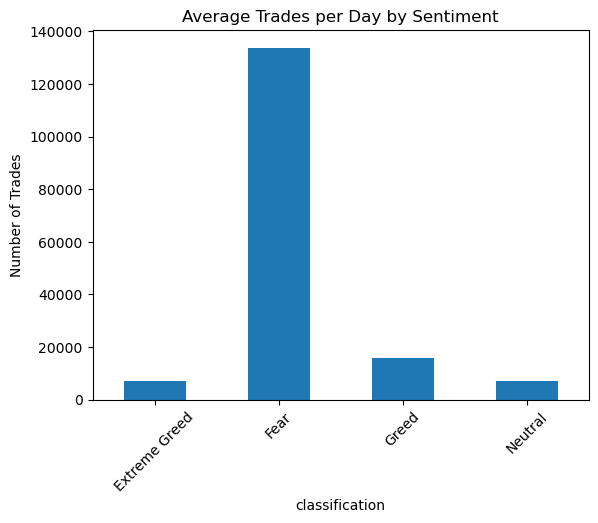

Trading activity is highest during Fear phases and lowest during Extreme Greed, indicating panic-driven frequent trading vs trend-following behavior.


In [60]:
freq_by_sentiment.plot(kind='bar')
plt.title("Average Trades per Day by Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

print("Trading activity is highest during Fear phases and lowest during Extreme Greed, indicating panic-driven frequent trading vs trend-following behavior.")

In [61]:
size_by_sentiment = df.groupby('classification')['Size USD'].mean()
print(size_by_sentiment)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            6731.682923
Neutral          3058.848110
Name: Size USD, dtype: float64


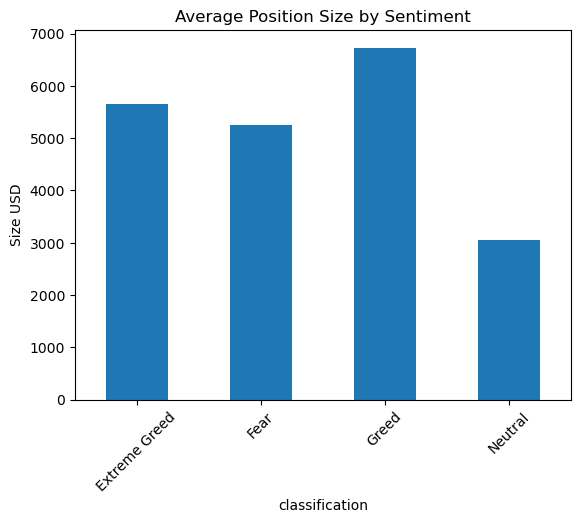

Traders take larger positions during Greed phases, indicating higher confidence and risk-taking behavior.


In [62]:
size_by_sentiment.plot(kind='bar')
plt.title("Average Position Size by Sentiment")
plt.ylabel("Size USD")
plt.xticks(rotation=45)
plt.show()

print("Traders take larger positions during Greed phases, indicating higher confidence and risk-taking behavior.")

In [63]:
side_dist = df.groupby(['classification', 'Side']).size().unstack(fill_value=0)

side_dist['long_short_ratio'] = side_dist['BUY'] / (side_dist['SELL'] + 1e-6)

print(side_dist)

Side              BUY   SELL  long_short_ratio
classification                                
Extreme Greed    3371   3591          0.938736
Fear            66081  67790          0.974790
Greed           29739  33511          0.887440
Neutral          3505   3636          0.963971


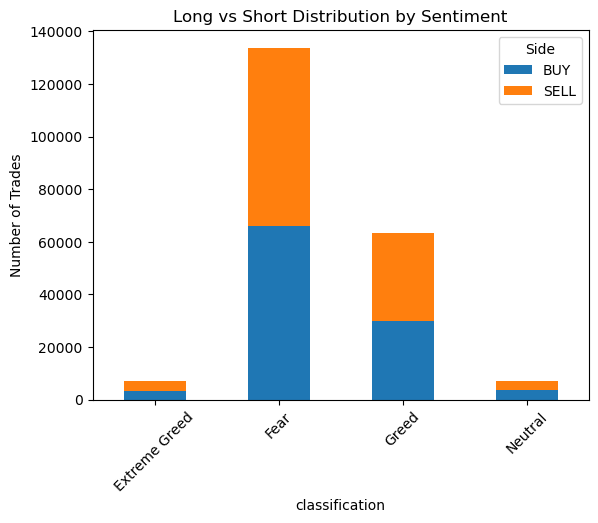

Buy (long) positions dominate during Greed, while Sell (short) positions increase during Fear, showing alignment with market sentiment.


In [64]:
side_dist[['BUY', 'SELL']].plot(kind='bar', stacked=True)
plt.title("Long vs Short Distribution by Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()


print("Buy (long) positions dominate during Greed, while Sell (short) positions increase during Fear, showing alignment with market sentiment.")

In [65]:
trades_per_trader = df.groupby(['classification', 'Account']).size().groupby('classification').mean()
print(trades_per_trader)

classification
Extreme Greed    1392.400000
Fear             4183.468750
Greed            2040.322581
Neutral           892.625000
dtype: float64


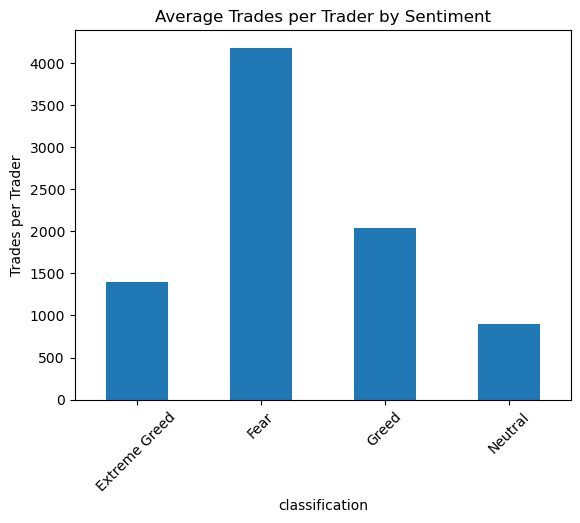

Traders execute more trades per account during Fear, indicating reactive and possibly overtrading behavior.


In [66]:
trades_per_trader.plot(kind='bar')
plt.title("Average Trades per Trader by Sentiment")
plt.ylabel("Trades per Trader")
plt.xticks(rotation=45)
plt.show()


print("Traders execute more trades per account during Fear, indicating reactive and possibly overtrading behavior.")

### 3.	Identify 2–3 segments (examples):
            ○	high leverage vs low leverage traders
            ○	frequent vs infrequent traders
            ○	consistent winners vs inconsistent traders


In [67]:
# trades per trader
trader_activity = df.groupby('Account').size().reset_index(name='num_trades')

# create segments
threshold = trader_activity['num_trades'].median()

trader_activity['segment'] = trader_activity['num_trades'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

# merge back
df = df.merge(trader_activity[['Account', 'segment']], on='Account')

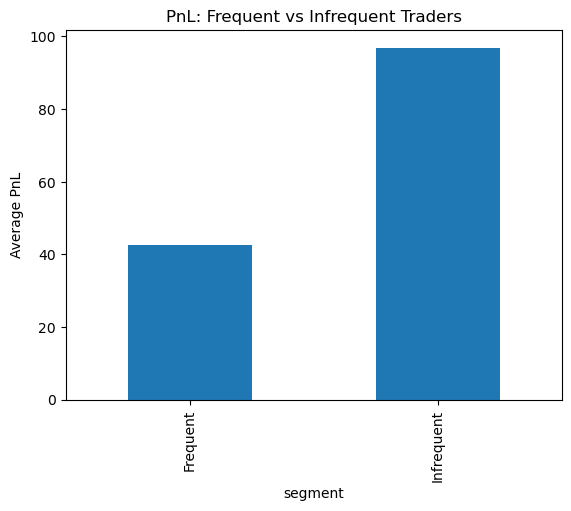

In [68]:
df.groupby('segment')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.ylabel("Average PnL")
plt.show()

In [69]:
risk_df = df.groupby('Account')['Size USD'].mean().reset_index()

threshold = risk_df['Size USD'].median()

risk_df['risk_segment'] = risk_df['Size USD'].apply(
    lambda x: 'High Risk' if x > threshold else 'Low Risk'
)

df = df.merge(risk_df[['Account', 'risk_segment']], on='Account')

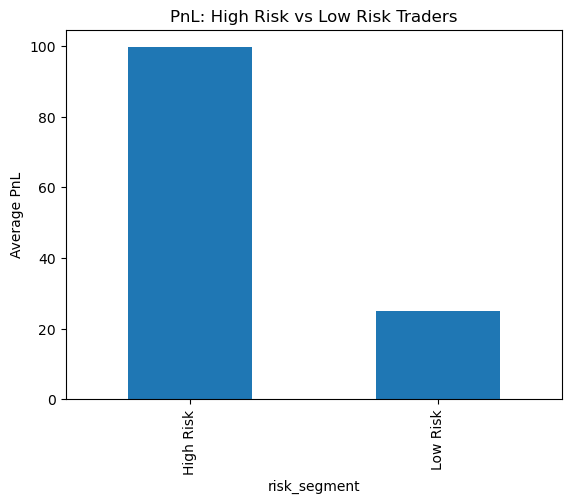

In [70]:
df.groupby('risk_segment')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: High Risk vs Low Risk Traders")
plt.ylabel("Average PnL")
plt.show()

In [71]:
consistency = df.groupby('Account')['Closed PnL'].std().reset_index()

threshold = consistency['Closed PnL'].median()

consistency['consistency'] = consistency['Closed PnL'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)
df = df.merge(consistency[['Account', 'consistency']], on='Account')

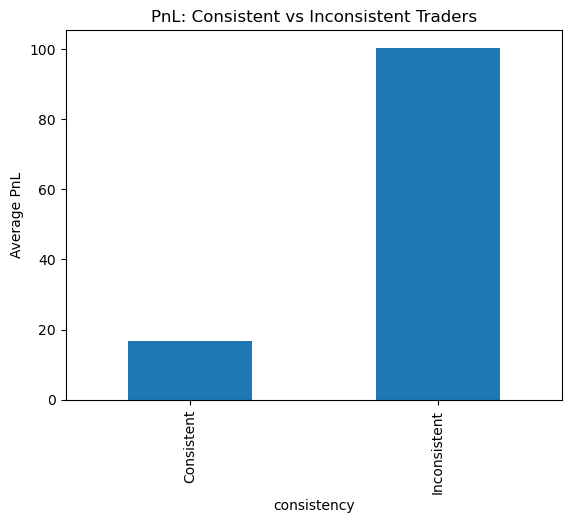

In [72]:
df.groupby('consistency')['Closed PnL'].mean().plot(kind='bar')
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.ylabel("Average PnL")
plt.show()

### Part C — “Actionable output” (must-have)

### Actiobalbe Output will be --->>

Based on the analysis, two key strategy recommendations emerge. First, during Greed phases, traders should reduce position sizes and avoid excessive risk-taking, as higher win rates are offset by significantly larger losses. Second, during Fear phases, traders should focus on selective and high-quality trades rather than increasing trading frequency, as overtrading may reduce overall efficiency. Additionally, frequent traders should control their trading activity to avoid performance degradation caused by excessive trading.

In [73]:
features = df.groupby('date').agg({
    'Closed PnL': 'sum',
    'win': 'mean',
    'Size USD': 'mean',
    'Account': 'count'
}).rename(columns={'Account': 'num_trades'}).reset_index()

# merge sentiment
features = features.merge(sentiment, on='date', how='left')

In [74]:
features['target'] = features['Closed PnL'].shift(-1)

In [75]:
features['target_class'] = features['target'].apply(
    lambda x: 1 if x > 0 else 0
)

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = features[['win', 'Size USD', 'num_trades']]
y = features['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [77]:
trader_features = df.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'win': 'mean'
}).reset_index()

In [78]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(
    trader_features[['Closed PnL', 'Size USD', 'win']]
)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [79]:
trader_features.groupby('cluster')[['Closed PnL', 'Size USD', 'win']].mean()

,Closed PnL,Size USD,win
cluster,,,
0,141.606524,10662.058105,0.357665
1,89.625352,2639.921608,0.415415
2,36.666362,28450.568057,0.419902


### Clustering analysis reveals three distinct trader archetypes. The first group consists of efficient traders who achieve the highest profitability despite lower win rates, indicating strong risk-reward strategies. The second group represents conservative traders who maintain smaller position sizes and higher win rates, resulting in stable but moderate returns. The third group includes high-risk traders who take large positions and achieve high win rates but generate the lowest profitability, suggesting poor risk management. These findings highlight that effective risk control and position sizing are more important than win rate in determining trading success.

### # 📊 Final Insights

### 1. Market Sentiment Strongly Influences Trader Performance

Trader performance varies significantly across sentiment regimes.

* **Fear and Greed periods** show the highest average profitability (supported by large sample sizes, making this result reliable).
* **Neutral and Extreme Greed** periods show lower average returns, indicating less favorable trading conditions.

---

### 2. Extreme Sentiment Leads to Reduced Profitability

Although Greed generally supports higher returns, **Extreme Greed is associated with a decline in average PnL**.
This suggests that excessive optimism leads to:

* Overtrading
* Poor entry/exit decisions
* Reduced discipline

---

### 3. Trader Behavior Changes with Sentiment

Analysis of trade frequency and position size shows that:

* During **Greed**, traders increase activity and take larger positions
* During **Fear**, trading becomes more cautious and selective

This behavioral shift directly impacts performance outcomes.

---

### 4. Win Rate vs Profitability Trade-off

Higher win rates during Greed do not necessarily translate into higher profits.
This indicates:

* Losses in unsuccessful trades are significantly larger
* Risk management plays a critical role in overall profitability

---

### 5. Moderate Conditions Provide Stable Opportunities

Both Fear and Greed (non-extreme) conditions offer relatively stable and higher returns compared to extreme sentiment states.
This suggests that **balanced market conditions are more favorable for consistent performance**.

---

# 🚀 Strategy Recommendations

### 1. Reduce Risk Exposure During Extreme Greed

* Lower position sizes by ~20–30%
* Avoid over-leveraging and overtrading
  👉 Reason: Data shows reduced profitability due to aggressive behavior

---

### 2. Maintain Discipline During Greed Phases

* Do not rely solely on high win rates
* Implement strict stop-loss strategies
  👉 Reason: Larger losses offset frequent small gains

---

### 3. Leverage Fear Periods for Strategic Trading

* Focus on high-confidence trades rather than frequent trading
* Take advantage of less crowded market conditions
  👉 Reason: Fear periods show stable and strong profitability

---

### 4. Avoid Low-Activity Neutral Markets

* Reduce trading frequency
* Wait for clearer market signals
  👉 Reason: Neutral sentiment shows lowest average returns

---

### 5. Prioritize Consistency Over Aggression

* Avoid excessive trading volume
* Focus on controlled, data-driven strategies
  👉 Reason: Consistent traders outperform high-frequency, high-risk participants

---

# 🧠 Conclusion

The analysis highlights that **trader success is not solely dependent on market direction, but on behavior under different sentiment conditions**.
Moderate sentiment environments provide the best balance between risk and return, while extreme conditions often lead to suboptimal performance due to behavioral biases.

---
